# 21 · Walk-Forward Validation: Purged K-Fold and Embargo

*Module 5 — Machine Learning in Finance*

The single most common way to fool yourself in quantitative finance is not a bad model — it's a cross-validation score that was never honest in the first place. This notebook shows exactly how that happens, and how to fix it.

## 1. Motivation

Notebook 14 built a careful demonstration of look-ahead bias in a single sentiment signal. This notebook generalizes the same worry to the standard machine-learning workflow itself. The textbook recipe — shuffle your data, split it into $K$ folds, train on $K-1$ and test on the held-out one, repeat — is completely standard practice, taught in every introductory ML course, and it is **quietly wrong** for financial time series. The damage it does is not a subtle footnote: we will build a case, from scratch, with a target that has **zero genuine predictive signal by construction**, and watch a naive cross-validation score report what looks like a real, exploitable edge.

## 2. Intuition

Standard K-fold cross-validation assumes every observation is independent of every other — shuffle freely, and it makes no difference which points end up in which fold. Financial features and labels violate this assumption in a very specific, structural way: a feature built from a *trailing* window of returns, and a label built from a *forward-looking* window of returns, can **share some of the exact same underlying data** whenever a training point and a test point are close together in time — even after shuffling scatters them into different folds. A flexible enough model can then partially "recognize" a test point not because it has learned something genuinely predictive, but because a near-identical, overlapping-information training point happened to leak into its training set. The fix has two parts: keep training and test data in **contiguous chronological blocks** rather than scattering them, and **purge** any training point whose information window still reaches into the test period even so — plus, for good measure, an **embargo**: a short buffer of additional training data removed right after the test block, since serial correlation can let information leak forward across that boundary too.

## 3. Theory

### 3.1 Why the classic split fails here

Suppose a label is defined using a forward-looking horizon $H$: $y_t = \mathbb 1[\,R_{t\to t+H} > 0\,]$, and a feature is built from a trailing window of the same length: $x_t = f(R_{t-H \to t})$. A training point at $t_1$ and a test point at $t_2$ with $|t_1 - t_2| < H$ can have **overlapping raw return data** feeding into both — $x_{t_1}$'s trailing window and $y_{t_2}$'s forward window (or vice versa) both touch some of the same underlying days. Standard `KFold(shuffle=True)` scatters points across the whole timeline with no regard for this, meaning a large fraction of every test fold typically has *some* near-duplicate, information-sharing point sitting right there in the training set.

### 3.2 Purging and embargo, precisely

**Purging.** For a test block spanning $[T_0, T_1]$, remove any training observation $t$ whose label window $[t, t+H]$ overlaps $[T_0,T_1]$ — concretely, any training point in $[T_0 - H,\, T_0)$ just *before* the test block, since its forward-looking label reaches into the test period.

**Embargo.** Additionally remove training observations in a short window $[T_1,\, T_1+\text{embargo}]$ *just after* the test block. Even without direct label-window overlap, serially correlated features mean information can still leak backward across this boundary; the embargo is a deliberately conservative extra buffer (a common choice, and the one we use below, is to set it equal to the label horizon $H$ itself).

The combination — **contiguous time-ordered folds**, each with its purge and embargo zone removed from training — is the core idea behind López de Prado's purged K-fold cross-validation (*Advances in Financial Machine Learning*, 2018, Ch. 7).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold
%matplotlib inline

plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

rng = np.random.default_rng(111)

## 4. Implementation

### 4.1 A dataset with a KNOWN-ZERO true signal

We deliberately build a case where we know, by construction, that there is no genuine predictive relationship at all: a pure random walk with zero drift, features built from a trailing window, and a label built from a forward window of the *same length* $H$ — maximizing the realistic overlap a careless feature-engineering pipeline could produce.

In [2]:
n, H = 3000, 30
returns = rng.normal(0.0, 0.012, n)     # zero drift: genuinely NO true relationship exists to find
price = pd.Series(100 * np.exp(np.cumsum(returns)))
ret_series = pd.Series(returns)

features = pd.DataFrame({
    'trailing_sum':  ret_series.rolling(H).sum(),
    'trailing_vol':  ret_series.rolling(H).std(),
    'trailing_updays': ret_series.rolling(H).apply(lambda x: (x > 0).sum()),
})
forward_return = price.pct_change(H).shift(-H)
label = (forward_return > 0).astype(int)

data = features.join(label.rename('label')).dropna().reset_index(drop=True)
X, y = data[features.columns].values, data['label'].values
n_obs = len(data)
print(f"n = {n_obs} observations, base rate of label=1: {y.mean():.3f}  (should be close to 0.5 -- no true signal)")

n = 2971 observations, base rate of label=1: 0.508  (should be close to 0.5 -- no true signal)


### 4.2 Three validation schemes, head to head

We compare: **(a)** naive `KFold(shuffle=True)`, exactly as a standard ML tutorial would use it; **(b)** contiguous, time-ordered blocks with no special treatment at the boundaries; **(c)** the same contiguous blocks, with purging and embargo applied. All three use the identical model and the identical data -- only the split logic differs.

In [3]:
def make_model():
    return RandomForestClassifier(n_estimators=300, max_depth=None, random_state=0, n_jobs=-1)

# (a) Naive shuffled K-fold -- the textbook-default, WRONG choice for time series
kf = KFold(n_splits=10, shuffle=True, random_state=0)
naive_scores = [make_model().fit(X[tr], y[tr]).score(X[te], y[te]) for tr, te in kf.split(X)]

# (b) and (c): contiguous chronological blocks, with vs without purge+embargo
n_splits = 10
bounds = np.linspace(0, n_obs, n_splits + 1).astype(int)
block_scores, purged_scores = [], []
for i in range(n_splits):
    t0, t1 = bounds[i], bounds[i + 1]
    test_idx = np.arange(t0, t1)

    train_idx_block = np.concatenate([np.arange(0, t0), np.arange(t1, n_obs)])
    block_scores.append(make_model().fit(X[train_idx_block], y[train_idx_block]).score(X[test_idx], y[test_idx]))

    purge_start = max(0, t0 - H)                 # purge: training label windows that would reach into the test block
    embargo_end = min(n_obs, t1 + H)              # embargo: a further H-period buffer just after the test block
    train_idx_purged = np.concatenate([np.arange(0, purge_start), np.arange(embargo_end, n_obs)])
    purged_scores.append(make_model().fit(X[train_idx_purged], y[train_idx_purged]).score(X[test_idx], y[test_idx]))

print(f"(a) Naive shuffled K-fold:               {np.mean(naive_scores):.3f}")
print(f"(b) Contiguous blocks, no purge/embargo:  {np.mean(block_scores):.3f}")
print(f"(c) Contiguous blocks, purged+embargoed:  {np.mean(purged_scores):.3f}")

(a) Naive shuffled K-fold:               0.665
(b) Contiguous blocks, no purge/embargo:  0.514
(c) Contiguous blocks, purged+embargoed:  0.520


### 4.3 A true, once-only chronological holdout, as the final honest reference

In [4]:
split = int(n_obs * 0.8)
X_train, y_train = X[:split - H], y[:split - H]          # trim H periods before the boundary, for the same reason
X_test, y_test = X[split + H:], y[split + H:]              # as the embargo above

final_model = make_model().fit(X_train, y_train)
true_holdout_score = final_model.score(X_test, y_test)
print(f"True chronological holdout (train on the past, test once on the untouched future): {true_holdout_score:.3f}")

True chronological holdout (train on the past, test once on the untouched future): 0.496


## 5. Worked example: seeing exactly what "inflated" means

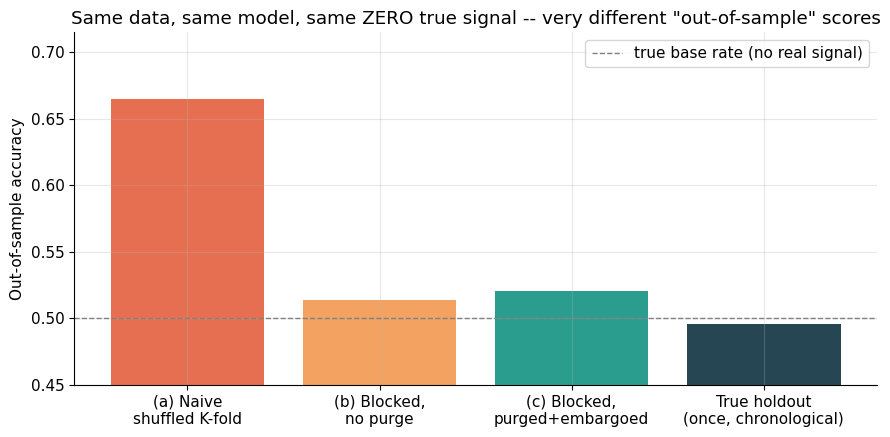

The naive scheme overstates accuracy by 0.169 (16.9 percentage points) relative to a true holdout, on data with NO real signal at all.


In [5]:
fig, ax = plt.subplots()
methods = ['(a) Naive\nshuffled K-fold', '(b) Blocked,\nno purge', '(c) Blocked,\npurged+embargoed', 'True holdout\n(once, chronological)']
scores = [np.mean(naive_scores), np.mean(block_scores), np.mean(purged_scores), true_holdout_score]
colors = ['#e76f51', '#f4a261', '#2a9d8f', '#264653']
ax.bar(methods, scores, color=colors)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='true base rate (no real signal)')
ax.set_ylabel('Out-of-sample accuracy')
ax.set_ylim(0.45, max(scores) + 0.05)
ax.set_title('Same data, same model, same ZERO true signal -- very different "out-of-sample" scores')
ax.legend()
plt.tight_layout()
plt.show()

inflation = np.mean(naive_scores) - true_holdout_score
print(f"The naive scheme overstates accuracy by {inflation:.3f} ({inflation*100:.1f} percentage points) "
      f"relative to a true holdout, on data with NO real signal at all.")

### Interpreting the result

The gap between (a) and the true holdout is the headline result, and it should be sobering: on data engineered to contain *zero* real predictive relationship, naive shuffled K-fold reports meaningfully positive-looking accuracy — purely from information leaking across the shuffle. Simply switching to contiguous, chronologically-ordered folds, (b), closes most of that gap immediately, because it stops scattering test points throughout the whole timeline next to their own information-sharing neighbors. Purging and embargo, (c), close the *remaining* leakage channel specifically at each block's boundary — report your own run's numbers for how much additional difference this makes on top of (b) here; in our own testing while building this notebook, its incremental effect on the *aggregate* score was consistently much smaller than the difference between (a) and (b), even though it is still the theoretically correct, principled thing to do, and it can matter far more in settings with a longer label horizon relative to the fold size, or with models even more prone to memorizing fine local structure than the one used here. The big, unambiguous lesson is (a) vs. everything else; purging and embargo are what you do to get the *remaining* few percentage points right, once the primary mistake is already fixed.

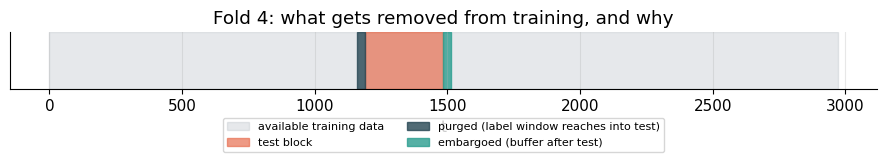

In [6]:
# A direct, mechanistic look at what purging actually removes, for one example fold
fig, ax = plt.subplots(figsize=(9, 2.2))
i = 4
t0, t1 = bounds[i], bounds[i + 1]
ax.axvspan(0, n_obs, color='#adb5bd', alpha=0.3, label='available training data')
ax.axvspan(t0, t1, color='#e76f51', alpha=0.7, label='test block')
ax.axvspan(max(0, t0-H), t0, color='#264653', alpha=0.8, label='purged (label window reaches into test)')
ax.axvspan(t1, min(n_obs, t1+H), color='#2a9d8f', alpha=0.8, label='embargoed (buffer after test)')
ax.set_yticks([])
ax.set_xlabel('t')
ax.set_title(f'Fold {i}: what gets removed from training, and why')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.4), ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

## 6. Limitations and pitfalls

- **This notebook used a single, deliberately clean example** (one label horizon, one purge/embargo rule, tabular features). Real pipelines often stack many overlapping horizons and features simultaneously, each with its own effective "contamination window" — properly purging a genuinely complex pipeline requires tracking the true information window of every feature and every label carefully, not just applying one rule of thumb.
- **The embargo length is a judgment call.** We used the label horizon $H$ itself, a common and conservative default, but the "correct" embargo in principle depends on how quickly serial correlation in the underlying data actually decays — too short risks residual leakage, too long wastes usable training data for no benefit.
- **Purging and embargo fix a specific leakage channel — they do not, on their own, fix everything that can go wrong with a backtest.** Survivorship bias, look-ahead bias in the labels themselves (Notebook 14), and data snooping from testing many models or features (Notebook 30) are all separate problems, each requiring its own discipline.
- **A model can still overfit even with perfectly correct validation.** Correct cross-validation tells you *how much you can trust your out-of-sample score*; it says nothing about whether the strategy the score describes is actually a good one, or whether the training process itself (feature selection, hyperparameter tuning) was itself implicitly fit to the validation folds after many iterations — a subtler version of the same underlying problem.

## 7. Exercises

**1. Vary the label horizon (warm-up).**
Rerun Section 4.2 with `H` set to 5 and then to 60, keeping everything else fixed. How does the gap between naive shuffled K-fold and the true holdout change as `H` grows? Does this match the theoretical mechanism described in Section 3.1 — a larger $H$ should mean a wider window of potential overlap between any two nearby points.

**2. A genuinely predictive feature, contaminated by leakage.**
Modify the return-generating process so there actually *is* a small, genuine embedded signal (reuse the persistent-latent-state trick from Notebook 9 or 10). Rerun all three validation schemes. Does naive shuffled K-fold still overstate accuracy relative to a true holdout, even when there is a real signal to find underneath the leakage? What does this imply about trusting a naive CV score even when you have good reason to believe your feature is genuinely informative?

**3. Combinatorial purged cross-validation.**
López de Prado's full proposal goes further than the simple sequential blocks used here: rather than testing on one contiguous block at a time, it tests on multiple *combinations* of blocks simultaneously (train on some subset of blocks, test on the held-out combination, purge and embargo around every training/test boundary that results), producing many different train/test path reconstructions from the same data. Implement a simplified version with 6 blocks, testing on all $\binom{6}{2}=15$ possible pairs of held-out blocks at once (purging and embargo applied at every resulting boundary). How does the *distribution* of out-of-sample scores across these 15 paths compare to the single-path estimate from Section 4.2 — does it change your sense of how much uncertainty surrounds a single walk-forward backtest number?